# Return Distribution Analysis
For our prices to be GBM, our log prices must be Brownian motion (BM). This means that the difference series (i.e. log returns) must be normally distributed, not autocorrelated, and homoskedastic in time. This notebook focuses on evaluating the validity of these assumptions for our chosen stock, PG. 

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, jarque_bera, shapiro, probplot, kstest
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.distributions.empirical_distribution import ECDF

In [79]:
df = pd.read_csv("../data/pg_daily.csv", index_col="date")

In [80]:
def pvalue_handler(p: float, test_name: str, trait: str, pos_direction: bool = True, alpha: float = 0.05):
    print(test_name, "p-value:", p)

    not_incl_null = " not" if not pos_direction else ""
    not_incl_alt = " NOT" if pos_direction else ""

    if p >= alpha:
        print(f"No evidence to reject the null - the data may{not_incl_null} be", trait)
    else:
        print(f"Reject the null - the data is{not_incl_alt}", trait)


## Normality of Log Returns

There are various tests we may use for testing for normality. The most well known are Jarque-Bera (JB), Shapiro-Wilk (SW), and Kolmogorov-Smirnov (KS). Each of these have as their null hypothesis that the data was generated from a normal distribution. This means that in each case we are looking for lack of evidence to reject the null. This carries the caveat that we can never truly conclude that our data is normally distributed using these tests, only confidently conclude that it is not, if the tests dail.

To somewhat mitigate this, we will run all three of the tests mentioned above, to look for any evidence that our data is not normally distributed. 

#### 1. The Jarque-Bera Test

The JB test uses a test statistic that is based on the sample skew and kurtosis that is $\chi^2_2$ distributed under the null hypothesis that the skew and kurtosis of the underlying distribution are 0 and 3 respectively (the quantities for the normal distribution). 

In [81]:
_, jb_pvalue = jarque_bera(df['log_return'].dropna())

In [82]:
pvalue_handler(jb_pvalue, "Jarque-Bera", "normally distributed")

Jarque-Bera p-value: 0.0
Reject the null - the data is NOT normally distributed


#### 2. The Shapiro-Wilk Test

The SW test essentially compares the sample percentiles to the normal distribution percentiles, similar to a Q-Q plot. Under the null hypothesis this plot should cluster around the "$y=x$" line. 

In [83]:
mu_hat = df["log_return"].mean()
sigma_hat = df["log_return"].std()

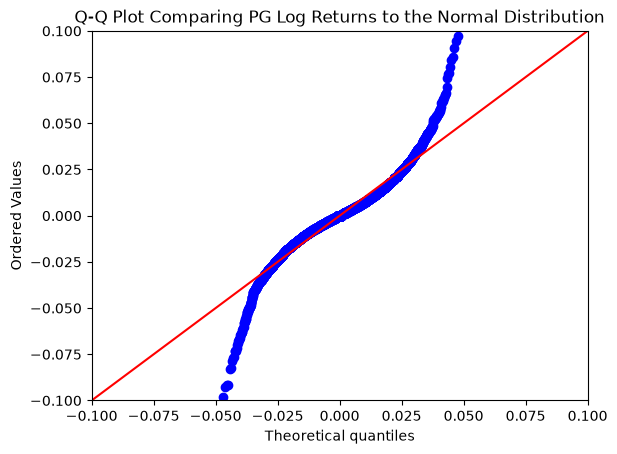

In [84]:
probplot(df['log_return'], dist="norm", sparams=(mu_hat, sigma_hat), plot=plt)
plt.axline((0, 0), slope=1, color='red')

plt.title("Q-Q Plot Comparing PG Log Returns to the Normal Distribution")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

plt.show()

In [85]:
_, sw_pvalue = shapiro(df['log_return'].dropna())

/Users/benjones/Projects/quant-finance/equity-random-walk-exploration/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16282.
  res = hypotest_fun_out(*samples, **kwds)


In [86]:
pvalue_handler(sw_pvalue, "Shapiro-Wilk", "normally distributed")

Shapiro-Wilk p-value: 1.1323151624931547e-74
Reject the null - the data is NOT normally distributed


#### 3. The Kolmogorov-Smirnov Test

The KS test is a more general distribution test that compares the CDF plot of any distribution (in our case normal) to the empirical CDF plot for the data.

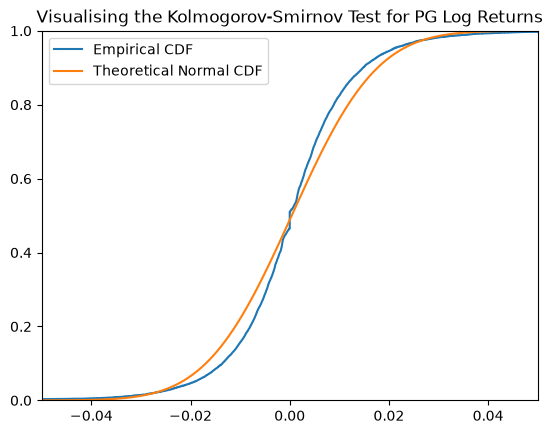

In [87]:
ecdf = ECDF(df['log_return'].dropna())
x = np.sort(df['log_return'].dropna())

plt.step(ecdf.x, ecdf.y, label='Empirical CDF')
plt.plot(x, norm.cdf(x, loc=mu_hat, scale=sigma_hat), label='Theoretical Normal CDF')
plt.xlim(-0.05, 0.05)
plt.ylim(0, 1)
plt.title("Visualising the Kolmogorov-Smirnov Test for PG Log Returns")
plt.legend()

In [88]:
_, ks_pvalue = kstest(df['log_return'].dropna(), norm(loc=mu_hat, scale=sigma_hat).cdf)

In [89]:
pvalue_handler(ks_pvalue, "Kolmogorov-Smirnov", "normally distributed")

Kolmogorov-Smirnov p-value: 1.0087099007912637e-67
Reject the null - the data is NOT normally distributed


#### 4. The Eye Test

Lastly, we will apply the not so rigorous "eye test" by plotting the density of our data against the PDF of a normal distribution with its mean and standard deviation as the sample mean and sample standard deviation respectively.

In [90]:
x = np.linspace(mu_hat - 4*sigma_hat, mu_hat + 4*sigma_hat, 1000)
y = norm.pdf(x, loc=mu_hat, scale=sigma_hat)

In [91]:
sigma_hat

np.float64(0.013511087448842836)

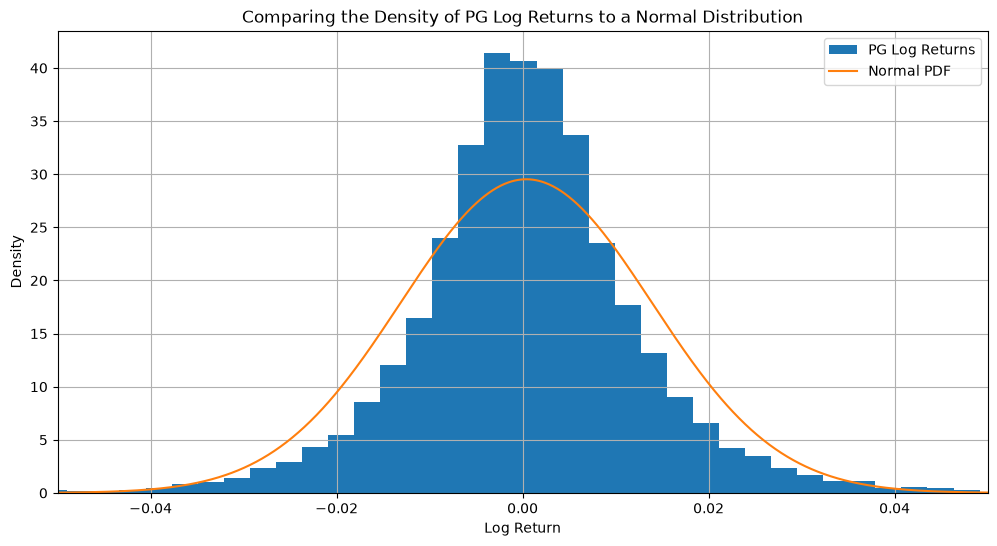

In [92]:
plt.figure(figsize=(12, 6))

df["log_return"].hist(bins=200, density=True, label="PG Log Returns")
plt.plot(x, y, label=f"Normal PDF")

plt.xlim(-0.05, 0.05)
plt.title("Comparing the Density of PG Log Returns to a Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

All three of our tests provided evidence to reject the null and conclude that log returns are not normally distributed. This is in line with a well-documented stylised fact of log returns, that they have fatter tails than normal distributions (Cont, 2001, [Empirical Properties of Asset Returns: Stylized Facts and Statistical Issues](https://doi.org/10.1080/713665670)). In future work, there are interesting opportunities to model log returns more accurately, such as using [Merton's Jump Diffusion model (1976)](https://doi.org/10.1016/0304-405X(76)90022-2), however this is beyond the scope of this project.

## Homoskedasticity

A time series is homoskedastic if its variance is constant in time. We can test this by fitting an autoregressive conditional heteroskedasticity (ARCH) model, which models the variance at time $t$ as a linear combination of the squared shocks from the previous $k$ time periods (lags), then by testing whether this* linear model's coefficients are nonzero using the Lagrange multiplier test. This approach was devised by Engle in his [1982 paper](https://doi.org/10.2307/1912773). The null hypothesis is therefore that the time series is homoskedastic and the alternative is that it is heteroskedastic, that is that the variance varies through time.

In terms of how many lags to test, we choose $k=10$, roughly two trading weeks, a semi-arbitrary reasonable horizon over which volatility shocks might plausibly persist.

It should be noted that this test technically required normality which we have already rejected, so the p-value itself should not be taken on face value, and we will supplement the test with a plot of the rolling standard deviation.

###### *note: in practice, the test can be and is conducted using an auxiliary model regressing the squared shocks themselves on their own lags.

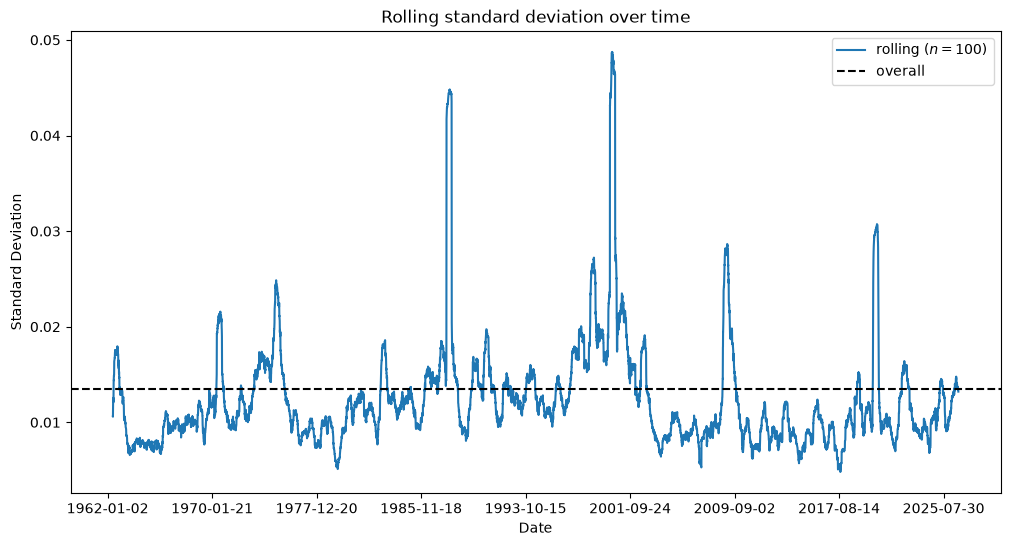

In [145]:
plt.figure(figsize=(12, 6))

df['log_return'].rolling(100).std().plot(label="rolling ($n=100$)")
plt.axhline(y=df['log_return'].std(), label="overall ", color='black', linestyle='--')


plt.title("Rolling standard deviation over time")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.legend()
plt.show()

In [121]:
_, arch_pvalue, _, _ = het_arch(df['log_return'].dropna(), nlags=10)

/Users/benjones/Projects/quant-finance/equity-random-walk-exploration/.venv/lib/python3.13/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [126]:
pvalue_handler(arch_pvalue, "ARCH (Lagrange multiplier)", "homoskedastic")

ARCH (Lagrange multiplier) p-value: 7.586675590169065e-125
Reject the null - the data is NOT homoskedastic


The figure above, supported by the ARCH test, shows that standard deviation, and hence variance, varies dramatically over time. This is another assumption of GBM that our data does not satisfy.

## Autocorrelation

To test for autocorrelation/serial correlation, we will use the Ljung-Box (LB) test (documented in their [1978 paper](https://doi.org/10.1093/biomet/65.2.297)). This uses the following test statistic:

$$ Q = n(n+2)\sum_{i=1}^{k} \frac{r_i^2}{n - i} $$

Where $n$ is the sample size, $r_i$ is the sample correlation at lag $i$, and $k$ is the number of lags being tested. This statistic is asymptotically $\chi^2_{k}$ distributed Under $H_0$. An important note here is that the LB test assumes homoskedasticity. Given the ARCH effects identified in the previous section, this test is not entirely valid in this setting. [Diebold (1986)](https://www.sas.upenn.edu/~fdiebold/papers2/Diebold%20(1987).pdf) shows that Ljung-Box statistics can substantially over-reject under conditional heteroskedasticity. We will conduct the test regardless, treating the result as indicative rather than confirmatory.

In terms of how many lags to test, we will choose $k=10$ for constistency with the homoskedasticity test.



In [ ]:
lb_pvalue = acorr_ljungbox(df['log_return'].dropna(), lags=[10])["lb_pvalue"].values[0]

Ljung-Box p-value: 2.4501895738019944e-10
Reject the null - the data is autocorrelated


In [151]:
pvalue_handler(lb_pvalue, "Ljung-Box", "autocorrelated", pos_direction=False)

Ljung-Box p-value: 2.4501895738019944e-10
Reject the null - the data is autocorrelated


In [150]:
acorr_ljungbox(df['log_return'].dropna(), lags=10)

,lb_stat,lb_pvalue
1,1.846602,1.741791e-01
2,17.135994,1.900931e-04
3,17.358282,5.963997e-04
4,62.234215,9.834411e-13
5,62.338381,3.990914e-12
6,62.944681,1.132779e-11
7,62.948522,3.881086e-11
8,63.800914,8.326997e-11
9,65.738150,1.036364e-10
10,66.141505,2.450190e-10


The LB test conclusion is to reject the null hypothesis and conclude that there is autocorrelation present in the data. However, due to the homoskedasticity assumption being violated as stated above, this result should be treated with great caution. That said, it is interesting to note that the test statistic is relatively low for a lag of 1, then increases dramatically at lags 2 and 4. There may be a legitimate effect here, or it could be the result of the assumption violation. Either way, this is beyond the scope of this project and will be noted as potential future work.

A more rigorous alternative to the LB test exists in the form of the modified Q* test ([Lobato, Nankervis and Savin, 2001](https://doi.org/10.1111/1468-2354.00106)), which tests for autocorrelation without assuming statistical independence. However, given that the test does not exist as a neatly importable function in mainstream python packages, and that the other two assumptions are already violated anyway, it does not make sense to explore this test here. 

## Conclusion

In this notebook we have 
- rejected normality of log returns,
- rejected homoskedasticity under the caveat that the normality assumption was violated (with the plot being a rather convincing support),
- found evidence of autocorrelation under the large caveat of the homoskedasticity assumption likely being violated.

It is important to keep in mind that there are dependencies here in that the first conclusion meant that we had to treat the second with caution, and likewise from the second to the third. But this provides a nice fallback in the sense that if our first conclusion is erroneous, then the second becomes more trustworthy (because the normality assumption is not then violated), and if both of those are erroneous, then the third becomes more trustworthy. In any case (unless all three are erroneous), one or more of the assumptions that are required for GBM is violated. 